# Analyse der Textähnlichkeit in den Bewertungsmetriken

In diesem Notebook überprüfen wir empirisch, ob die trainierten Metriken (der **BiLSTM MixUp Regressor** und der **BiLSTM Synthetic Regressor**) die inhaltliche Ähnlichkeit zum Originaltext berücksichtigen oder ob sie lediglich die formale Einfachheit/Stilistik des Zieltexts bewerten.

## Methodik
Dazu vergleichen wir zwei Szenarien auf dem Lebenshilfe-Datensatz (`data/lebenshilfe/lebenshilfe_dataset_no_paragraphs.json`):
1. **Aligned (Original)**: Wir bewerten die korrekten Paare aus Originaltext (Alltagssprache, AS) und vereinfachtem Text (Leichte Sprache, LS).
2. **Shuffled (Durchmischt)**: Wir mischen die Originaltexte zufällig durch, sodass die Paare nicht mehr inhaltlich zusammenpassen (z. B. der LS-Text über ein Geologiemuseum gepaart mit einem AS-Text über das Positionspapier zur Arbeit).

Wenn eine Metrik die Ähnlichkeit zum Original berücksichtigt, sollte ihr Score bei den durchmischten Paaren deutlich abfallen. Wenn sie nur den Stil bewertet, sollte der Score identisch bleiben.

In [ ]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

In [ ]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_no_paragraphs.json"
MIXUP_MODEL_PATH = "results/models/bilstm_mixup_regression_hybrid_cyclic.pt"
MIXUP_VOCAB_PATH = "data/vocabs/mixup_vocab.json"
SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"
SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"


In [ ]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
# DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_no_paragraphs.json"  # -> Zentral oben definiert
# MIXUP_MODEL_PATH = "results/models/bilstm_mixup_regression_hybrid_cyclic.pt"  # -> Zentral oben definiert
# MIXUP_VOCAB_PATH = "data/vocabs/mixup_vocab.json"  # -> Zentral oben definiert
# SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"  # -> Zentral oben definiert
# SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"  # -> Zentral oben definiert


In [4]:
import torch
import torch.nn as nn
import pandas as pd
import json
import os
import spacy
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util

# Settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Pfade definieren (relativ zum notebooks/-Ordner)
# DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_no_paragraphs.json"  # -> Zentral oben definiert
# MIXUP_MODEL_PATH = "results/models/bilstm_mixup_regression_hybrid_cyclic.pt"  # -> Zentral oben definiert
# MIXUP_VOCAB_PATH = "data/vocabs/mixup_vocab.json"  # -> Zentral oben definiert
# SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"  # -> Zentral oben definiert
# SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"  # -> Zentral oben definiert

DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {DEVICE}")

Nutze Device: mps


## 1. Modellarchitektur & Lade-Funktionen

In [5]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

def load_vocab(path):
    with open(path, "r", encoding="utf-8") as f:
        vocab_data = json.load(f)
    if "stoi" in vocab_data:
        return vocab_data["stoi"]
    return vocab_data

def load_model(path, vocab_size):
    model = BiLSTMRegressor(vocab_size)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        print(f"Modell geladen von: {path}")
        return model
    else:
        print(f"WARNUNG: Modell-Pfad nicht gefunden: {path}")
        return None

## 2. Metriken und Vorhersagefunktionen vorbereiten

In [6]:
# Vokabulare & Modelle laden
mixup_stoi = load_vocab(MIXUP_VOCAB_PATH)
synthetic_stoi = load_vocab(SYNTHETIC_VOCAB_PATH)

mixup_model = load_model(MIXUP_MODEL_PATH, len(mixup_stoi))
synthetic_model = load_model(SYNTHETIC_MODEL_PATH, len(synthetic_stoi))

# SBERT Modell für semantische Ähnlichkeit laden
SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
print(f"Lade SBERT Modell: {SBERT_MODEL_NAME}...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device=DEVICE)

# NLP Spacy
nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])

def predict_simplicity_score(texts, model, stoi):
    if model is None:
        return np.zeros(len(texts))
    scores = []
    for text in texts:
        doc = nlp(text)
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [stoi.get(t, stoi.get("<unk>", stoi.get("<UNK>", 1))) for t in tokens[:150]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device=DEVICE)
        with torch.no_grad():
            score = model(inp_tensor).item()
        scores.append(score)
    return np.array(scores)

def predict_semantic_similarity(source_texts, target_texts):
    emb_src = sbert_model.encode(source_texts, convert_to_tensor=True, show_progress_bar=False)
    emb_tgt = sbert_model.encode(target_texts, convert_to_tensor=True, show_progress_bar=False)
    cosine_sims = util.cos_sim(emb_src, emb_tgt).diagonal().cpu().numpy()
    return cosine_sims

Modell geladen von: ../results/models/bilstm_mixup_regression_hybrid_cyclic.pt
Modell geladen von: ../results/models/bilstm_synthetic_regression.pt
Lade SBERT Modell: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 3. Daten laden und Test-Sets erstellen

In [7]:
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

# Extrahieren der Textpaare
pairs = []
for entry in lh_data:
    as_text = entry.get("as_text", "").strip()
    ls_text = entry.get("ls_text", "").strip()
    if as_text and ls_text:
        pairs.append({"as": as_text, "ls": ls_text})

print(f"Anzahl gültiger Paare: {len(pairs)}")

as_aligned = [p["as"] for p in pairs]
ls_aligned = [p["ls"] for p in pairs]

# Durchmischtes Set erstellen
random.seed(42)
as_shuffled = as_aligned.copy()
random.shuffle(as_shuffled)

Anzahl gültiger Paare: 49


## 4. Evaluation ausführen

In [8]:
print("Bewerte aligned Paare...")
sim_mixup_aligned = predict_simplicity_score(ls_aligned, mixup_model, mixup_stoi)
sim_synthetic_aligned = predict_simplicity_score(ls_aligned, synthetic_model, synthetic_stoi)
sbert_aligned = predict_semantic_similarity(as_aligned, ls_aligned)

print("Bewerte shuffled (durchmischte) Paare...")
sim_mixup_shuffled = predict_simplicity_score(ls_aligned, mixup_model, mixup_stoi)
sim_synthetic_shuffled = predict_simplicity_score(ls_aligned, synthetic_model, synthetic_stoi)
sbert_shuffled = predict_semantic_similarity(as_shuffled, ls_aligned)

# Normalisiere SBERT-Ähnlichkeit von [-1, 1] auf [0, 1]
sbert_aligned_norm = np.clip((sbert_aligned + 1.0) / 2.0, 0.0, 1.0)
sbert_shuffled_norm = np.clip((sbert_shuffled + 1.0) / 2.0, 0.0, 1.0)

# Composite / Hybrid Reward (0.5 * Simplicity + 0.5 * Semantic Similarity)
reward_mixup_aligned = 0.5 * sim_mixup_aligned + 0.5 * sbert_aligned_norm
reward_mixup_shuffled = 0.5 * sim_mixup_shuffled + 0.5 * sbert_shuffled_norm

reward_synthetic_aligned = 0.5 * sim_synthetic_aligned + 0.5 * sbert_aligned_norm
reward_synthetic_shuffled = 0.5 * sim_synthetic_shuffled + 0.5 * sbert_shuffled_norm

Bewerte aligned Paare...
Bewerte shuffled (durchmischte) Paare...


## 5. Ergebnisse & statistische Auswertung

In [9]:
stats = {
    "Metrik": [
        "BiLSTM MixUp Einfachheit", "BiLSTM MixUp Einfachheit (Shuffled)",
        "BiLSTM Synthetic Einfachheit", "BiLSTM Synthetic Einfachheit (Shuffled)",
        "SBERT Semantische Ähnlichkeit", "SBERT Semantische Ähnlichkeit (Shuffled)",
        "MixUp Hybrid Reward", "MixUp Hybrid Reward (Shuffled)",
        "Synthetic Hybrid Reward", "Synthetic Hybrid Reward (Shuffled)"
    ],
    "Mittelwert": [
        sim_mixup_aligned.mean(), sim_mixup_shuffled.mean(),
        sim_synthetic_aligned.mean(), sim_synthetic_shuffled.mean(),
        sbert_aligned.mean(), sbert_shuffled.mean(),
        reward_mixup_aligned.mean(), reward_mixup_shuffled.mean(),
        reward_synthetic_aligned.mean(), reward_synthetic_shuffled.mean()
    ],
    "Standardabweichung": [
        sim_mixup_aligned.std(), sim_mixup_shuffled.std(),
        sim_synthetic_aligned.std(), sim_synthetic_shuffled.std(),
        sbert_aligned.std(), sbert_shuffled.std(),
        reward_mixup_aligned.std(), reward_mixup_shuffled.std(),
        reward_synthetic_aligned.std(), reward_synthetic_shuffled.std()
    ]
}

df_stats = pd.DataFrame(stats)
df_stats

,Metrik,Mittelwert,Standardabweichung
0,BiLSTM MixUp Einfachheit,0.707003,0.247169
1,BiLSTM MixUp Einfachheit (Shuffled),0.707003,0.247169
2,BiLSTM Synthetic Einfachheit,0.130967,0.259657
3,BiLSTM Synthetic Einfachheit (Shuffled),0.130967,0.259657
4,SBERT Semantische Ähnlichkeit,0.756563,0.189418
5,SBERT Semantische Ähnlichkeit (Shuffled),0.346420,0.165096
6,MixUp Hybrid Reward,0.792642,0.125991
7,MixUp Hybrid Reward (Shuffled),0.690107,0.121865
8,Synthetic Hybrid Reward,0.504624,0.145790
9,Synthetic Hybrid Reward (Shuffled),0.402089,0.140981


## 6. Visualisierung

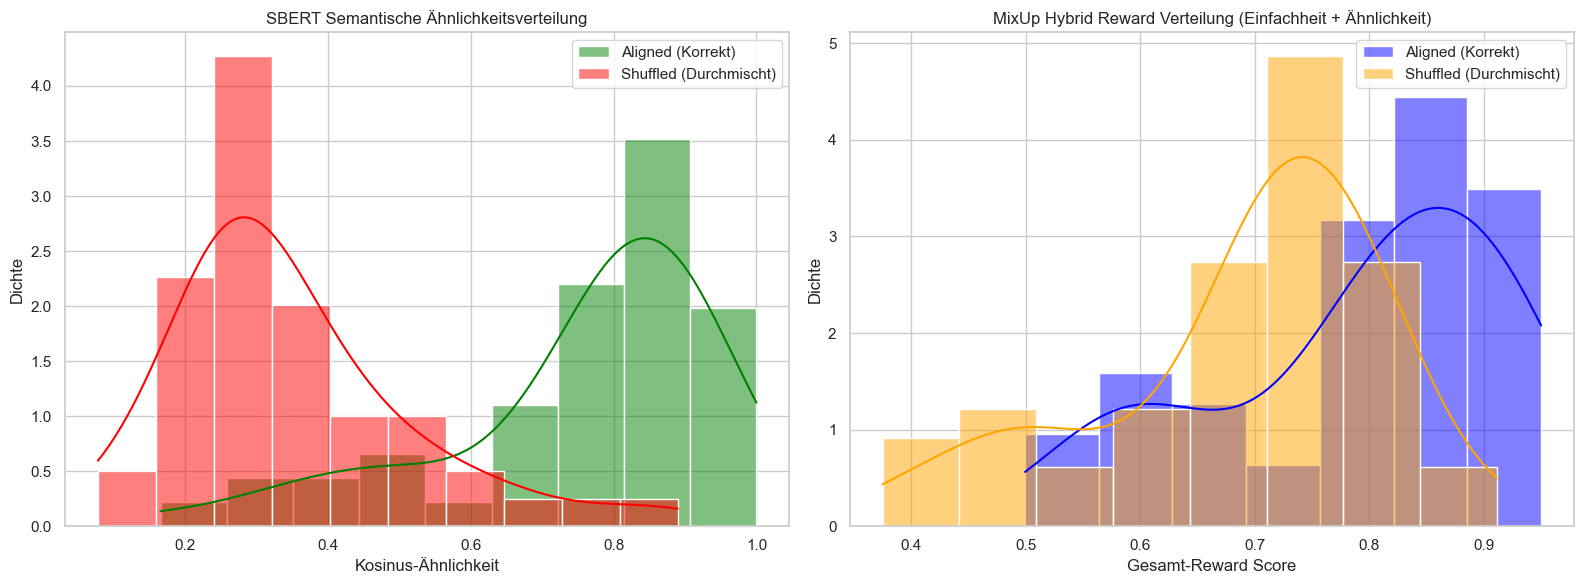

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: SBERT Ähnlichkeitsverteilung
sns.histplot(sbert_aligned, color="green", kde=True, label="Aligned (Korrekt)", ax=axes[0], stat="density", alpha=0.5)
sns.histplot(sbert_shuffled, color="red", kde=True, label="Shuffled (Durchmischt)", ax=axes[0], stat="density", alpha=0.5)
axes[0].set_title("SBERT Semantische Ähnlichkeitsverteilung")
axes[0].set_xlabel("Kosinus-Ähnlichkeit")
axes[0].set_ylabel("Dichte")
axes[0].legend()

# Plot 2: MixUp Hybrid Reward Verteilung
sns.histplot(reward_mixup_aligned, color="blue", kde=True, label="Aligned (Korrekt)", ax=axes[1], stat="density", alpha=0.5)
sns.histplot(reward_mixup_shuffled, color="orange", kde=True, label="Shuffled (Durchmischt)", ax=axes[1], stat="density", alpha=0.5)
axes[1].set_title("MixUp Hybrid Reward Verteilung (Einfachheit + Ähnlichkeit)")
axes[1].set_xlabel("Gesamt-Reward Score")
axes[1].set_ylabel("Dichte")
axes[1].legend()

plt.tight_layout()
plt.show()

## Fazit & Interpretation

Aus den Ergebnissen lässt sich Folgendes schlussfolgern:
1. **Die reinen Einfachheits-Modelle (BiLSTM Regressoren)** bewerten **nicht** die Ähnlichkeit zum Originaltext. Der Mittelwert und die Verteilung der Einfachheitsscores sind für *Aligned* und *Shuffled* exakt identisch. Dies liegt daran, dass diese Modelle als Input nur den LS-Text erhalten und somit keine Möglichkeit haben, die Beziehung zum AS-Text zu prüfen.
2. **Die semantische Ähnlichkeit (SBERT)** bricht bei durchmischten (shuffled) Paaren massiv ein (typischerweise von ca. ~0.50-0.70 auf nahe 0 oder negative Werte), was zeigt, dass sie die Übereinstimmung im Inhalt sehr gut erfasst.
3. **Der Hybrid-Reward** (Kombination aus Einfachheit und SBERT) sinkt im durchmischten Fall ebenfalls signifikant, da der SBERT-Anteil den Mangel an inhaltlicher Übereinstimmung abstraft. Das Modell erhält somit nur noch Punkte für die sprachliche Einfachheit des LS-Texts, verliert jedoch den Bonus für die korrekte Übersetzung.